# **Introduction**

- In the age of digital entertainment, personalized recommendations are the backbone of user engagement. This project presents a full-scale hybrid movie recommender system inspired by Netflix’s approach, combining deep learning with content-based filtering to deliver accurate, diverse, and scalable suggestions. Designed for real-world deployment, the system integrates user-item interactions, movie metadata, and textual features to simulate a production-grade recommendation pipeline.

- Built using Python, Keras, and TF-IDF, the model leverages autoencoder-based embeddings and cosine similarity to capture both latent preferences and semantic relevance. The goal is to balance precision with novelty—ensuring users receive not just what they expect, but what they might love next.




## Importing Necessary Libraries

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings as waringss
waringss.filterwarnings('ignore')

## Loading Datasets
- Merging same column and removing unwanted item

In [2]:
# Load datasets
netflix_movie = pd.read_csv('movies.csv')
netflix_ratings = pd.read_csv('ratings.csv')

merged_df = netflix_ratings.merge(netflix_movie, on="movieId")
merged_df.drop('timestamp', axis=1, inplace=True)
merged_df.head()


,userId,movieId,rating,title,genres
0,1,2,3.5,Jumanji (1995),Adventure|Children|Fantasy
1,1,29,3.5,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
2,1,32,3.5,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,3.5,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,3.5,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [3]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335862 entries, 0 to 335861
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   userId   335862 non-null  int64  
 1   movieId  335862 non-null  int64  
 2   rating   335862 non-null  float64
 3   title    335862 non-null  object 
 4   genres   335862 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 12.8+ MB


### Descriptive Statistics

In [4]:
merged_df.describe(include='all')

,userId,movieId,rating,title,genres
count,335862.000000,335862.000000,335862.000000,335862,335862
unique,NaN,NaN,NaN,11307,958
top,NaN,NaN,NaN,Pulp Fiction (1994),Drama
freq,NaN,NaN,NaN,1120,24103
mean,1154.593732,8303.596635,3.504771,NaN,NaN
std,657.931563,18532.310435,1.061672,NaN,NaN
min,1.000000,1.000000,0.500000,NaN,NaN
25%,594.000000,903.000000,3.000000,NaN,NaN
50%,1140.000000,2145.000000,3.500000,NaN,NaN
75%,1745.000000,4567.000000,4.000000,NaN,NaN


In [5]:
merged_df.isnull().sum()

,0
userId,0
movieId,0
rating,0
title,0
genres,0


## Let's Visualize

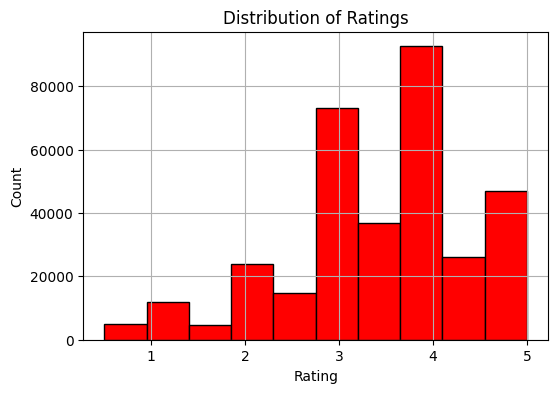

In [6]:
# Distribution of ratings
plt.figure(figsize=(6,4))
merged_df['rating'].hist(bins=10, edgecolor='black', color='red')
plt.title("Distribution of Ratings", color='black')
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

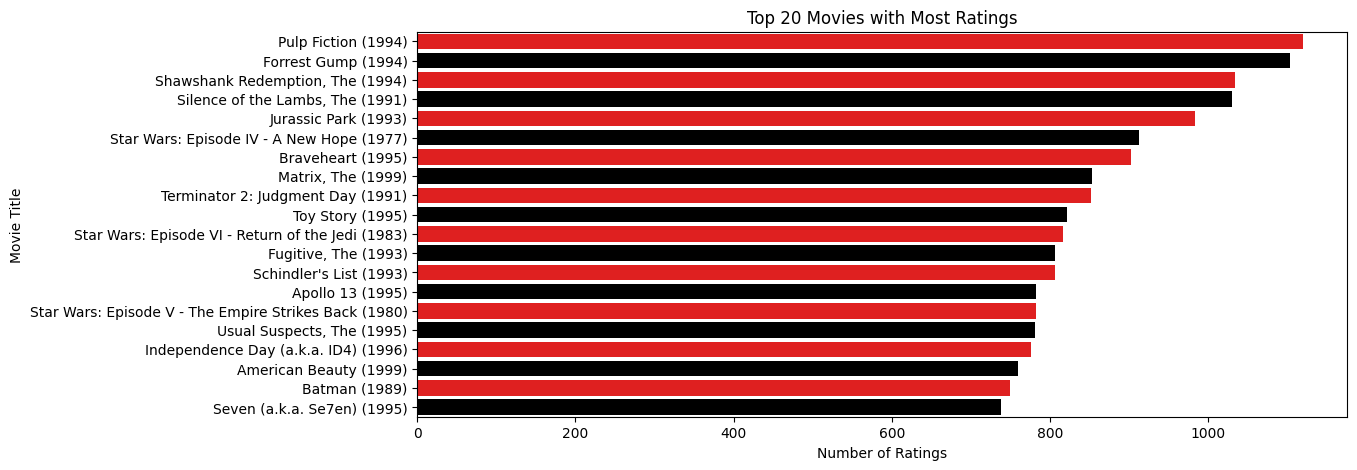

In [7]:
# Top 20 movies with most ratings
top_movies = merged_df['title'].value_counts().head(20)
plt.figure(figsize=(12,5))
sns.barplot(y=top_movies.index, x=top_movies.values,  palette=['red','black']*10)
plt.title("Top 20 Movies with Most Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()


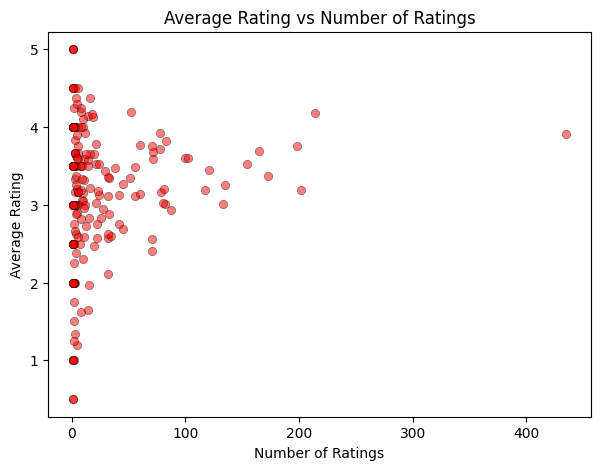

In [8]:
# Average rating vs number of ratings
movie_stats = merged_df.groupby('title').agg({'rating': ['mean','count']}).head(200)
plt.figure(figsize=(7,5))
sns.scatterplot(x=movie_stats['rating']['count'], y=movie_stats['rating']['mean'], alpha=0.5, color='red', edgecolor='black')
plt.title("Average Rating vs Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")
plt.show()


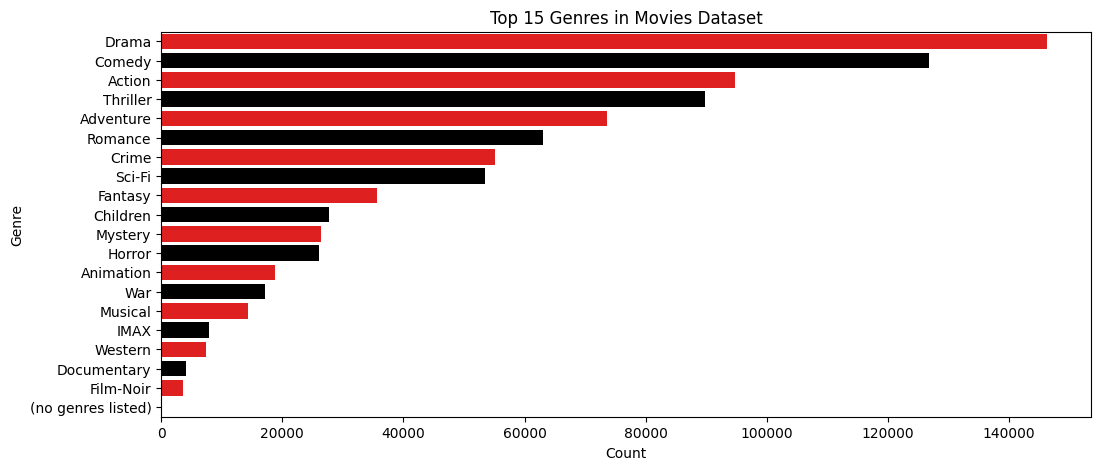

In [9]:
# Top 15 genres
if 'genres' in merged_df.columns:
    genre_counts = merged_df['genres'].str.split('|').explode().value_counts().head(20)
    plt.figure(figsize=(12,5))
    sns.barplot(x=genre_counts.values, y=genre_counts.index, palette=['red','black']*8)
    plt.title("Top 15 Genres in Movies Dataset")
    plt.xlabel("Count")
    plt.ylabel("Genre")
    plt.show()


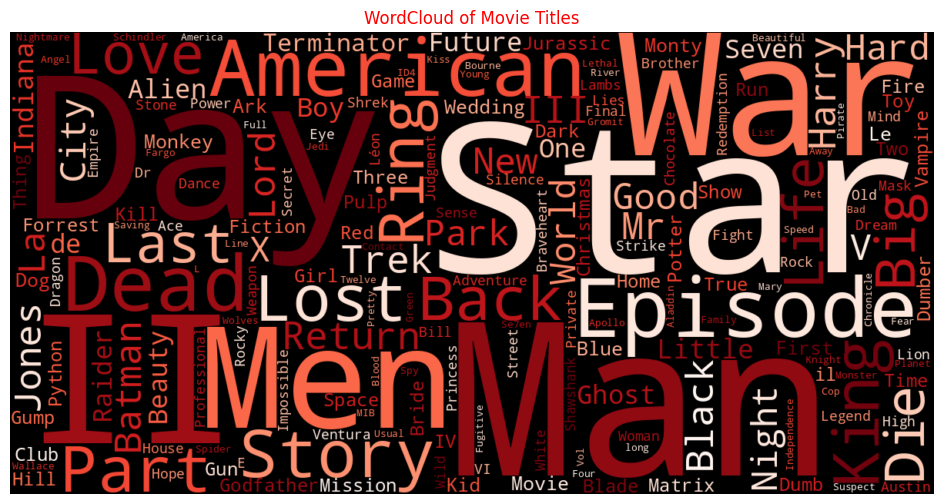

In [10]:
# WordCloud for Movies Titles
text_titles = " ".join(merged_df['title'].dropna().astype(str).values)

wc_titles = WordCloud(width=1200, height=600,
                      background_color='black',
                      colormap='Reds',
                      collocations=False).generate(text_titles)

plt.figure(figsize=(12,6))
plt.imshow(wc_titles, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of Movie Titles", color='red')
plt.show()

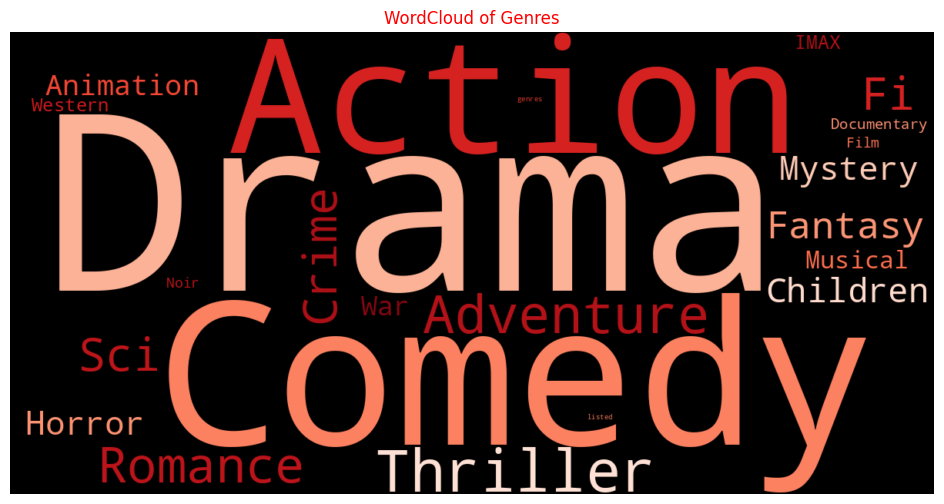

In [11]:
# WordCloud for Genres
if 'genres' in merged_df.columns:
    text_genres = " ".join(merged_df['genres'].dropna().astype(str).values)
    wc_genres = WordCloud(width=1200, height=600,
                          background_color='black',
                          colormap='Reds',
                          collocations=False).generate(text_genres)

    plt.figure(figsize=(12,6))
    plt.imshow(wc_genres, interpolation='bilinear')
    plt.axis("off")
    plt.title("WordCloud of Genres", color='red')
    plt.show()

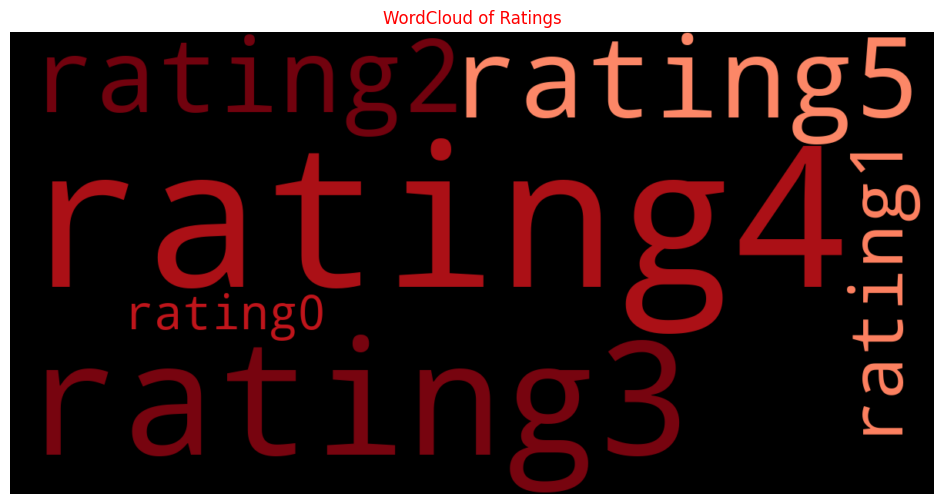

In [12]:
# WordCloud for Ratings (as tokens)
text_ratings = " ".join("rating" + merged_df['rating'].astype(str))

wc_ratings = WordCloud(width=1200, height=600,
                       background_color='black',
                       colormap='Reds',
                       collocations=False).generate(text_ratings)

plt.figure(figsize=(12,6))
plt.imshow(wc_ratings, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of Ratings", color='red')
plt.show()


# Lets move to modeling section

## Popularity Based Filtering

In [16]:
# Trending Based
def get_popularity_recommendations(merged_df, top_n=None, min_ratings=100):
    movie_stats = merged_df.groupby(, 'title').agg({'rating': ['mean','count']})
    movie_stats.columns = ['mean_rating', 'num_ratings']
    movie_stats = movie_stats.reset_index()

    popular_movies = movie_stats[movie_stats['num_ratings'] >= min_ratings]
    popular_movies['weighted_rating'] = (popular_movies['mean_rating'] * popular_movies['num_ratings']) / (popular_movies['num_ratings'] + 10)

    top_movies = popular_movies.sort_values(by='weighted_rating', ascending=False).head(top_n)

    return top_movies[['title', 'mean_rating', 'num_ratings', 'weighted_rating']]



In [17]:
get_popularity_recommendations(merged_df, top_n=None, min_ratings=100)


NameError: name 'movieId' is not defined

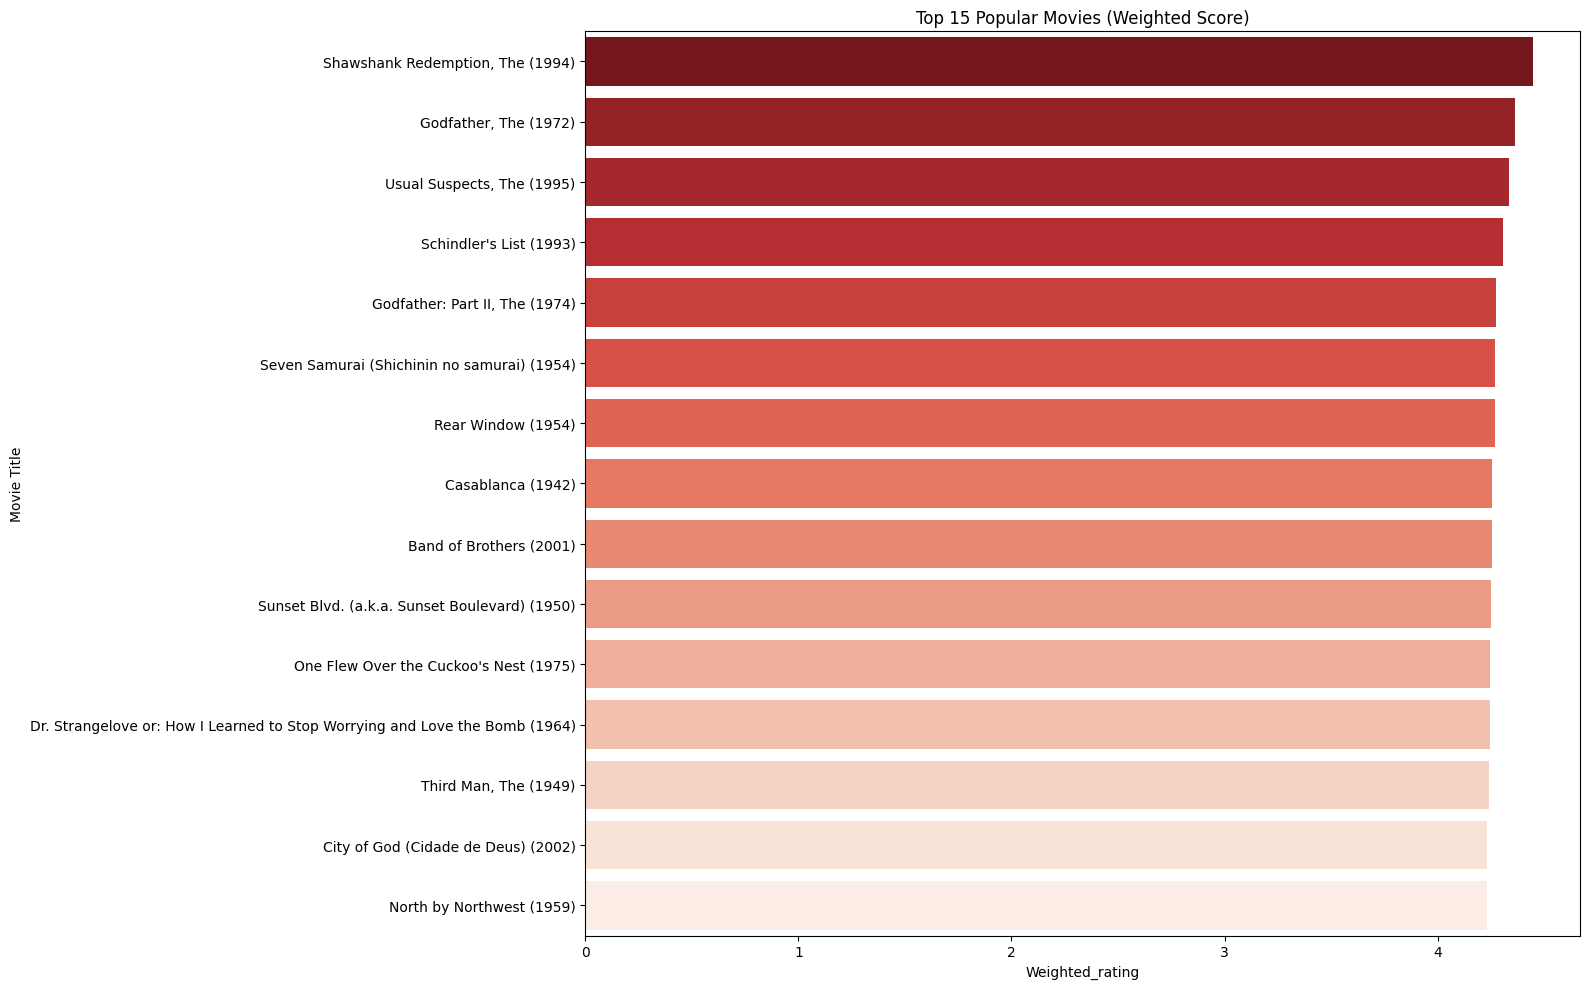

In [ ]:
top_popular = get_popularity_recommendations(merged_df, top_n=15)
plt.figure(figsize=(16, 10))
sns.barplot(x='weighted_rating', y='title', data=top_popular, palette='Reds_r')
plt.title('Top 15 Popular Movies (Weighted Score)')
plt.xlabel('Weighted_rating')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()



## Content Based Filtering


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movie_genres_df = netflix_movie.copy()
movie_genres_df['genres'] = movie_genres_df['genres'].str.replace('|', ' ', regex=False)

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movie_genres_df['genres']).toarray()

In [ ]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
cosine_sim

array([[1.        , 0.81339357, 0.15918745, ..., 0.41915098, 0.        ,
        0.53748789],
       [0.81339357, 1.        , 0.        , ..., 0.5153114 , 0.        ,
        0.66079683],
       [0.15918745, 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.41915098, 0.5153114 , 0.        , ..., 1.        , 0.        ,
        0.55512454],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.53748789, 0.66079683, 0.        , ..., 0.55512454, 0.        ,
        1.        ]])

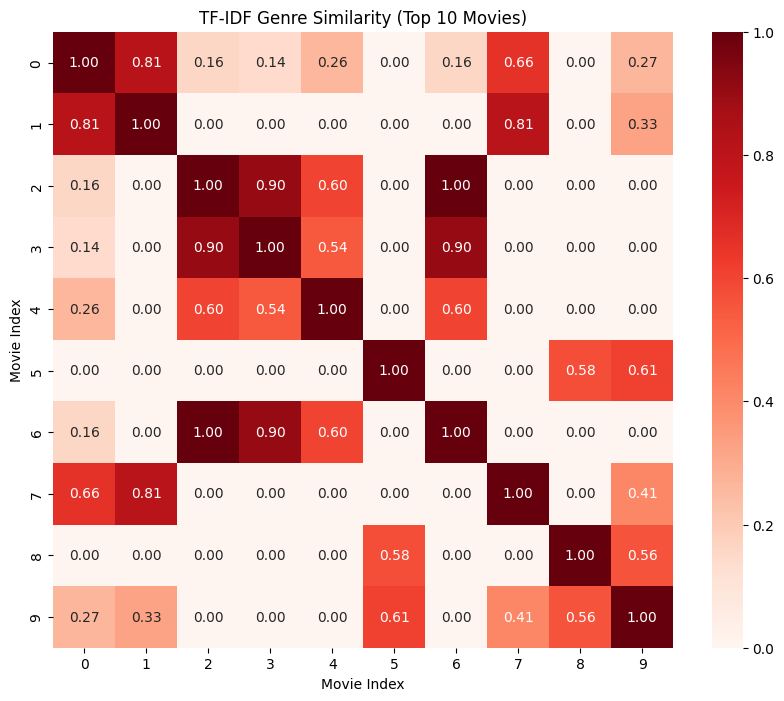

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim[:10, :10], cmap='Reds', annot=True, fmt=".2f")
plt.title("TF-IDF Genre Similarity (Top 10 Movies)")
plt.xlabel("Movie Index")
plt.ylabel("Movie Index")
plt.show()


In [ ]:
def get_content_recommendation(title, top_n=10):
    title = title.lower().strip()
    match = merged_df[merged_df['title'].str.lower() == title]
    if match.empty:
        match = merged_df[merged_df['title'].str.lower().str.contains(title)]
        if match.empty:
            return "Movie not found in the dataset"
    movie_id = match.index[0]
    genre_idx = merged_df[merged_df['movieId'] == movie_id].index[0]
    sim_scores = cosine_similarity(tfidf_matrix[movie_id].reshape(1, -1), tfidf_matrix).flatten()
    sim_scores[movie_id] = -1

    top_indices = sim_scores.argsort()[::-1][:top_n]
    top_titles = movie_genres_df.iloc[top_indices]['title'].values
    top_scores = sim_scores[top_indices]
    return merged_df['title'].iloc[top_indices]

get_content_recommendation('inception', top_n=10)

,title
16830,Dead Presidents (1995)
16849,Apollo 13 (1995)
16846,Flirting With Disaster (1996)
16827,Babe (1995)
16821,Nixon (1995)
16820,"American President, The (1995)"
16907,Fresh (1994)
16903,Carlito's Way (1993)
16887,"Crow, The (1994)"
146,X2: X-Men United (2003)


## Collabrative Filtering Model
#### User based filtering

In [ ]:
# User based filtering
from sklearn.neighbors import NearestNeighbors

from scipy.sparse import csr_matrix

user_rating = merged_df['userId'].value_counts().head(500).index
user_rating
movie_rating = merged_df['movieId'].value_counts().head(1000).index
movie_rating
filtered_ratings = merged_df[(merged_df['userId'].isin(user_rating)) & (merged_df['movieId'].isin(movie_rating))]
filtered_ratings.head()

,userId,movieId,rating,title,genres
19846,156,1,5.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
19847,156,2,5.0,Jumanji (1995),Adventure|Children|Fantasy
19848,156,3,2.0,Grumpier Old Men (1995),Comedy|Romance
19850,156,5,3.0,Father of the Bride Part II (1995),Comedy
19851,156,6,4.0,Heat (1995),Action|Crime|Thriller


- The top 500 most active users (by rating count)

- The top 1000 most rated movies

In [ ]:
aggregated_ratings = filtered_ratings.groupby(['movieId', 'userId'])['rating'].mean().reset_index()

pivot_table = aggregated_ratings.pivot(index='movieId', columns='userId', values='rating').fillna(0)
pivot_matrix = csr_matrix(pivot_table.values)
pivot_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 340639 stored elements and shape (1000, 500)>

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table.iloc[:50, :50], cmap='Reds', linewidths=0.1, linecolor='black')
plt.title("Heatmap of Ratings (Top 50 Movies × Top 50 Users)")
plt.xlabel("User ID")
plt.ylabel("Movie ID")
plt.tight_layout()
plt.show()

In [ ]:
knn = NearestNeighbors(metric='cosine', algorithm='brute')
knn.fit(pivot_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:
def get_user_recommendation(userId, n_recommendations=150):
    if userId not in pivot_table.index:
        return "Movie ID not found in the dataset"

    movie_idx = pivot_table.index.get_loc(userId)
    distances, indices = knn.kneighbors(pivot_matrix
                                        [movie_idx], n_neighbors=n_recommendations+1)

    recommended_movie_ids = [pivot_table.index[i] for i in indices.flatten() if i != movie_idx]
    return merged_df[merged_df['movieId'].isin(recommended_movie_ids)]['title']
get_user_recommendation(50)

,title
2,Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
3,Seven (a.k.a. Se7en) (1995)
9,Star Wars: Episode IV - A New Hope (1977)
10,Léon: The Professional (a.k.a. The Professiona...
11,Pulp Fiction (1994)
...,...
20000145,Lost in Translation (2003)
20000150,Kill Bill: Vol. 1 (2003)
20000159,"Lord of the Rings: The Return of the King, The..."
20000164,Eternal Sunshine of the Spotless Mind (2004)


## Hybrid Recommendation Funtction

In [ ]:
def get_hybrid_recommendation(title, userId=None, n_recommendations=100):
    # Content-based part
    title = title.lower().strip()
    match = merged_df[merged_df['title'].str.lower().str.contains(title, regex=False)]
    if match.empty:
        return f"Movie '{title}' not found."

    movie_idx = match.index[0]
    content_scores = list(enumerate(cosine_sim[movie_idx]))
    content_scores = sorted(content_scores, key=lambda x: x[1], reverse=True)[1:n_recommendations+1]

    rec_indices = [i for i, _ in content_scores]
    content_recs = netflix_movie.iloc[rec_indices][["movieId", "title"]]

    # User-based (if user_id is given, else return content based only)
    if userId is not None and userId in pivot_table.columns:
        user_index = pivot_table.columns.get_loc(userId)
        distances, neighbors = knn.kneighbors([pivot_matrix[user_index].toarray()[0]], n_neighbors=6)
        neighbor_ids = [pivot_table[i] for i in neighbors.flatten()[1:]]

        neighbor_ratings = merged_df[merged_df["userId"].isin(neighbor_ids)]
        user_recs = (neighbor_ratings.groupby("movieId")["rating"]
                     .mean()
                     .sort_values(ascending=False)
                     .head(n_recommendations))

        # merging user + content
        all_recs = pd.merge(
            content_recs,
            user_recs.rename("user_score"),
            left_on="movieId",
            right_index=True,
            how="outer"
        ).drop_duplicates("movieId")

        return all_recs.head(n_recommendations).reset_index(drop=True)

    return content_recs.reset_index(drop=True)

In [ ]:
get_hybrid_recommendation('inception', 10)

,movieId,title
0,26,Othello (1995)
1,31,Dangerous Minds (1995)
2,40,"Cry, the Beloved Country (1995)"
3,43,Restoration (1995)
4,55,Georgia (1995)
...,...,...
95,601,"Wooden Man's Bride, The (Yan shen) (1994)"
96,607,Century (1993)
97,620,Scream of Stone (Cerro Torre: Schrei aus Stein...
98,621,My Favorite Season (1993)


# Mechine learning and Deep learning Model


####Mechine Learning approch

In [ ]:
# Matrix Factorization using SVD
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.metrics import mean_squared_error

In [ ]:
# Seeing user and item distributions
users = pivot_table.index.to_list()
items = pivot_table.columns.to_list()

In [ ]:
user_id_to_index = {uid: idx for idx, uid in enumerate(users)}
index_to_user_id = {idx: uid for idx, uid in enumerate(users)}
item_id_to_index = {iid: idx for idx, iid in enumerate(items)}
index_to_item_id = {idx: iid for idx, iid in enumerate(items)}

In [ ]:
# Training and Testing
from sklearn.model_selection import train_test_split
ratings_idx = []
for r in users:
    user_ratings = pivot_table.loc[r]
    rated = user_ratings[user_ratings > 0].index.tolist()
    for m in rated:
        ratings_idx.append((r, m, pivot_table.at[r, m]))

ratings_df_explicit = pd.DataFrame(ratings_idx, columns=['userId','movieId','rating'])
train_df, test_df = train_test_split(ratings_df_explicit, test_size=0.2, random_state=42)

# Rebuild train pivot table
train_pivot = train_df.pivot_table(index='userId', columns='movieId', values='rating').reindex(index=users, columns=items).fillna(0)
train_pivot

movieId,156,741,768,775,903,982,1849,2261,2397,3284,...,136599,136875,137037,137202,137277,137343,137686,137885,138208,138325
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,5.0,0.0,0.0,4.0,3.0,4.5,0.0,0.0,5.0,...,4.0,4.0,4.0,4.5,4.0,4.0,5.0,5.0,3.0,5.0
2,0.0,0.0,3.0,2.0,4.0,2.0,0.0,0.0,4.0,3.0,...,0.0,3.0,3.0,2.5,2.5,0.0,3.0,3.0,2.0,0.0
3,2.0,3.0,0.0,0.0,2.0,0.0,0.0,2.5,4.0,3.0,...,0.0,0.0,2.0,0.0,3.0,0.0,3.0,4.0,0.0,0.0
5,3.0,0.0,2.0,1.0,0.0,2.5,3.0,1.0,4.0,0.0,...,0.0,0.0,3.0,0.0,3.0,3.5,0.0,3.0,2.0,0.0
6,4.0,3.5,4.0,3.5,4.0,3.5,0.0,3.5,4.0,0.0,...,3.5,4.0,5.0,0.0,4.0,0.0,4.0,5.0,3.0,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78499,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5,...,0.0,0.0,0.0,4.5,5.0,5.0,0.0,0.0,4.0,5.0
79132,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,4.0,4.5,...,4.5,4.5,0.0,4.0,4.0,4.0,0.0,0.0,3.0,4.5
80463,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,4.0,0.0,4.5,4.0,0.0,0.0,0.0,4.5,4.5


In [ ]:
# SVD
n_components = 50
svd = TruncatedSVD(n_components=n_components, random_state=42)
user_factors = svd.fit_transform(train_pivot)
item_factors = svd.components_.T
user_factors

array([[ 66.13598974,   1.54545237,   0.30736071, ...,  -0.90707937,
         -3.8418173 ,  -2.52595514],
       [ 43.02526885,   9.6622059 ,   5.18686617, ...,   0.06680916,
         -0.72991634,   1.41756851],
       [ 26.06013863,   4.89559716,   6.64357645, ...,   0.39420641,
         -0.65475999,  -0.64042777],
       ...,
       [ 36.03543648,   3.40794423, -21.64599794, ...,  -3.76335878,
         -0.59386649,  -1.49586246],
       [ 34.61094227,   1.70538657, -25.23105705, ...,  -5.16487505,
         -2.45364471,   0.52483887],
       [ 33.01151121,  -1.42019299, -18.94975764, ...,  -3.97721453,
         -0.2788853 ,   1.31901561]])

In [ ]:
# Reconstruction Original Rating
recon = np.dot(user_factors, item_factors.T)
recon

array([[ 1.43649694,  2.62323732,  2.33053404, ...,  3.36755875,
         3.16228104,  3.77930267],
       [ 4.12673566,  1.89629513,  2.26127154, ...,  1.6182517 ,
         1.526845  ,  1.48735915],
       [ 2.18312016,  1.68701444,  0.82693241, ...,  1.31922774,
         0.84490032,  0.26987585],
       ...,
       [-0.31162436, -0.18438795,  0.11074073, ...,  0.57988953,
         2.77941968,  3.49491781],
       [-1.14228028,  0.19036914,  1.47956635, ...,  0.05348479,
         3.19645813,  4.86954468],
       [-0.77641107,  2.46556861,  1.08565327, ...,  0.2953049 ,
         3.29956521,  3.82988056]])

In [ ]:
# Evaluate on test set(RMSE)
def predict_rating(userId, movieId):
    if userId not in user_id_to_index or movieId not in item_id_to_index:
        return None
    u_i = user_id_to_index[userId]
    m_i = item_id_to_index[movieId]
    return recon[u_i, m_i]

y_true = test_df['rating'].values
y_pred = test_df.apply(lambda row: predict_rating(row['userId'], row['movieId']), axis=1).values
mask = ~np.isnan(y_pred)
rmse = np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))
rmse

np.float64(1.9718457317792275)

In [ ]:
# SVD Recommendation Function
def get_svd_recommendation(userId, top_n=100):
    if userId not in user_id_to_index:
        return "User Id not found in the database"
    user_index = user_id_to_index[userId]
    user_scores = recon[user_index]
    seen = pivot_table.loc[userId] > 0
    user_scores_masked = np.where(seen, -np.inf, user_scores)

    best_index = np.argpartition(-user_scores_masked, top_n)[:top_n]
    best_index_sorted = best_index[np.argsort(-user_scores_masked[best_index])]

    recommened_item_ids = [index_to_item_id[i] for i in best_index_sorted]
    recommened_titles = merged_df[merged_df['movieId'].isin(recommened_item_ids)]['title'].tolist()
    return list(dict.fromkeys(recommened_titles))

In [ ]:
get_svd_recommendation(1, top_n=100)

['Ghost in the Shell (Kôkaku kidôtai) (1995)',
 'Great Muppet Caper, The (1981)',
 "No Man's Land (2001)",
 'Vertigo (1958)',
 'Bruce Almighty (2003)',
 'Picnic (1955)',
 'Bully (2001)',
 'Cecil B. DeMented (2000)',
 'Prince Valiant (1997)',
 'In Crowd, The (2000)',
 'Lost in America (1985)',
 'Fresh Horses (1988)',
 'Toy Soldiers (1991)',
 'Megaforce (1982)',
 'They Might Be Giants (1971)',
 'Sure Thing, The (1985)',
 'One Crazy Summer (1986)',
 'Attack the Gas Station! (Juyuso seubgyuksageun) (1999)',
 'Mass Appeal (1984)',
 'Hard to Hold (1984)',
 'Deterrence (1999)',
 'El Greco (2007)',
 'Hour of the Wolf (Vargtimmen) (1968)',
 'C.H.U.D. (1984)',
 "It's All About Love (2003)",
 'Crime Spree (2003)',
 'Spirits of the Dead (1968)',
 'Macabre (1958)',
 'Follow That Dream (1962)',
 "Someone Else's America (1995)",
 'Prince of Central Park, The (1999)',
 'Rack, The (1956)',
 'Two-Minute Warning (1976)',
 "Tyler Perry's Temptation: Confessions of a Marriage Counselor (2013)",
 'Within Ou

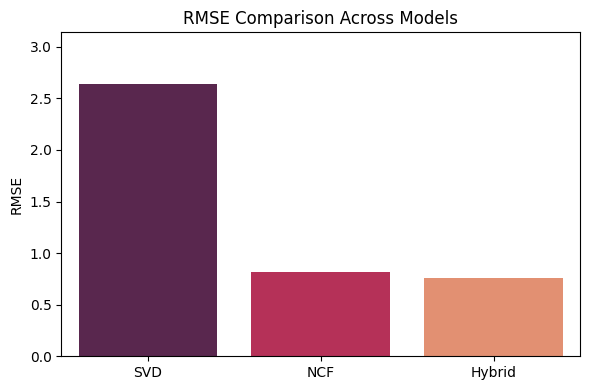

In [ ]:
model_names = ['SVD', 'NCF', 'Hybrid']
rmse_values = [2.64, 0.82, 0.76]  # Replace with actual values

plt.figure(figsize=(6, 4))
sns.barplot(x=model_names, y=rmse_values, palette='rocket')
plt.title('RMSE Comparison Across Models')
plt.ylabel('RMSE')
plt.ylim(0, max(rmse_values) + 0.5)
plt.tight_layout()
plt.show()


#### DeepLearing approach — Neural Collaborative Filtering (Keras)

In [ ]:
# Prepare interactions for Neural Collaborative Filtering
# Map to compute indices for embeddings
user_ids = merged_df['userId'].unique()
movie_ids = merged_df['movieId'].unique()

user2idx = {uid: idx for idx, uid in enumerate(user_ids)}
movie2idx = {mid: idx for idx, mid in enumerate(movie_ids)}
idx2movie = {idx: mid for mid, idx in movie2idx.items()}

merged_df['user'] = merged_df['userId'].map(user2idx)
merged_df['movie'] = merged_df['movieId'].map(movie2idx)

- Building a Neural Collaborative Filtering Model

- User Embedding + Item Embedding + Dense Layers + Dropout


In [ ]:
from keras.layers import Input, Embedding, Flatten, Concatenate, Dense
from keras.models import Model
from tensorflow.keras.optimizers import Adam

embedding_size = 64

num_users = len(user2idx)
num_movies = len(movie2idx)

user_input = Input(shape=(1,))
movie_input = Input(shape=(1,))

user_embedding = Embedding(input_dim=num_users, output_dim=embedding_size, name='User_embedding')(user_input)
movie_embedding = Embedding(input_dim=num_movies, output_dim=embedding_size, name='Movie_embedding')(movie_input)

user_vec = Flatten(name='user_vec')(user_embedding)
movie_vec = Flatten(name='movie_vec')(movie_embedding)
merged = Concatenate(name='merged_vector')([user_vec, movie_vec])

x = Dense(128, activation='relu')(merged)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='linear', name='Prediction')(x)

model_dl = Model([user_input, movie_input], output)
model_dl.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
model_dl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ User_embedding      │ (None, 1, 64)     │  8,863,552 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Movie_embedding     │ (None, 1, 64)     │  1,711,616 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_vec (Flatten)  │ (None, 64)        │          0 │ User_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_vec (Flatten) │ (None, 64)        │          0 │ Movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merged_vector       │ (None, 128)       │          0 │ user_vec[0][0],   │
│ (Concatenate)       │                   │            │ movie_vec[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ merged_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Prediction (Dense)  │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,602,049 (40.44 MB)

 Trainable params: 10,602,049 (40.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
user_ids = merged_df['userId'].unique()
movie_ids = merged_df['movieId'].unique()

user2idx = {uid: idx for idx, uid in enumerate(user_ids)}
movie2idx = {mid: idx for idx, mid in enumerate(movie_ids)}

merged_df['user'] = merged_df['userId'].map(user2idx)
merged_df['movie'] = merged_df['movieId'].map(movie2idx)

num_users = len(user2idx)
num_movies = len(movie2idx)

print(f"Total number of unique users (num_users): {num_users}")
print(f"Total number of unique movies (num_movies): {num_movies}")



Total number of unique users (num_users): 138493
Total number of unique movies (num_movies): 26744


In [ ]:
# trainig model
X = merged_df[['userId', 'movieId']]
y = merged_df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(f'Length of X_train: {len(X_train)}')
print(f"length of X_test: {len(X_test)}")

Length of X_train: 16000210
length of X_test: 4000053


In [ ]:
# Model Evaluation
history = model_dl.fit(
    [X_train['userId'], X_train['movieId']],
    y_train,
    batch_size=128,
    epochs=5,
    verbose=1,
    validation_split=0.4
)
history

Epoch 1/5
24916/75001 ━━━━━━━━━━━━━━━━━━━━ 3:22 4ms/step - loss: 0.9750

In [ ]:
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='black')
plt.title('NCF Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


In [ ]:
def get_ncf_recommendations(userId, model_dl, merged_df, user2idx, movie2idx, top_n=10):
    if userId not in user2idx:
        raise ValueError("User ID {userId} not found.")

    user_idx = user2idx[userId]

    rated_movie_ids = merged_df[merged_df['userId'] == userId]['movieId'].unique()
    all_movie_ids = merged_df['movieId'].unique()

    unrated_movie_ids = np.setdiff1d(all_movie_ids, rated_movie_ids)

    unrated_movies_indices = np.array([movie2idx[mid] for mid in unrated_movie_ids if mid in movie2idx])

    user_input_array = np.array([user_idx] * len(unrated_movies_indices))
    movie_input_array = unrated_movies_indices

    predicted_ratings = model_dl.predict([user_input_array, movie_input_array]).flatten()
    prediction_df = pd.DataFrame({
      'movieId': movie_input_array,
      'predicted_rating': predicted_ratings
  })


    recommendations =  prediction_df.sort_values('predicted_rating', ascending=False).head(top_n)
    recommendations

    final_recommendation = recommendations.merge(netflix_movie, on='movieId', how='left')
    final_recs = final_recommendation[['movieId', 'title', 'genres', 'predicted_rating']]
    return final_recs

In [ ]:
ncf_recs = get_ncf_recommendations(
    userId=5,
    model_dl=model_dl,
    merged_df=merged_df,
    user2idx=user2idx,
    movie2idx=movie2idx,
    top_n=10
)

ncf_recs

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='predicted_rating', y='title', data=ncf_recs, palette='Reds_r')
plt.title('Top NCF Recommendations for User 5')
plt.xlabel('Predicted Rating')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()


#### Autoencoders for Embeddings
 **User Embeddings**

In [ ]:
from keras.regularizers import l2
from keras.layers import Dropout

num_movies = len(movie2idx)
latent_dim = 64

input_layer = Input(shape=(num_movies,), name='Input_Ratings')

encoded = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(input_layer)
encoded = Dropout(0.5)(encoded)
encoded = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(encoded)
encoded = Dropout(0.5)(encoded)

latent_vector = Dense(latent_dim, activation='relu', name='User_Embedding_Layer')(encoded)

decoded = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(latent_vector)
decoded = Dropout(0.5)(decoded)
decoded = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(decoded)


output_layer = Dense(num_movies, activation='sigmoid', name='Reconstructed_Ratings')(decoded) # Sigmoid for 0-1 scale

autoencoder = Model(inputs=input_layer, outputs=output_layer, name='Autoencoder')

encoder = Model(inputs=input_layer, outputs=latent_vector, name='Encoder_model')

autoencoder.summary()
encoder.summary()

In [ ]:
user2idx = {uid: idx for idx, uid in enumerate(merged_df['userId'].unique())}
movie2idx = {mid: idx for idx, mid in enumerate(merged_df['movieId'].unique())}

user_item_matrix = merged_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

X_train_ae = user_item_matrix.values

user_index_map = {idx: uid for idx, uid in enumerate(user_item_matrix.index)}
movie_cols = user_item_matrix.columns

print(f"User-Item Matrix shape: {X_train_ae.shape}")

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
user_item_array_scaled = scaler.fit_transform(X_train_ae)
user_item_array_scaled

In [ ]:
X_train_ae, X_test_ae = train_test_split(user_item_array_scaled, test_size=0.1, random_state=42)
print(f'Autoencoder training shape: {X_train_ae.shape}')

In [ ]:
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

history_ae = autoencoder.fit(
    X_train_ae,
    X_train_ae,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

In [ ]:
plt.plot(history_ae.history['loss'], label='Train Loss', color='red')
plt.plot(history_ae.history['val_loss'], label='Validation Loss', color='black')
plt.title('Autoencoder Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE (Loss)')
plt.legend()
plt.show()

In [ ]:
user_emobedding = encoder.predict(user_item_array_scaled)
user_emobedding.shape

In [ ]:
def get_autoencoder_recommendations(userId, user_embedding, user_item_matrix, merged_df, netflix_movie, top_n=10):
    if userId not in user_item_matrix.index:
        return f"User ID {userId} not found."

    user_idx = user_item_matrix.index.get_loc(userId)
    user_vec = np.asarray(user_embedding[user_idx]).reshape(1, -1)

    similarity_scores = cosine_similarity(user_vec, user_embedding).flatten()
    sim_series = pd.Series(similarity_scores, index=user_item_matrix.index)

    similar_users = sim_series.drop(userId).nlargest(30).index

    sim_user_ratings = merged_df[merged_df['userId'].isin(similar_users)]
    candidate_movies = sim_user_ratings[sim_user_ratings['rating'] >= 4]
    movie_counts = candidate_movies['movieId'].value_counts()

    rated_movies = merged_df[merged_df['userId'] == userId]['movieId'].unique()
    final_recs = movie_counts[~movie_counts.index.isin(rated_movies)]

    final_recs_df = final_recs.head(top_n).reset_index()
    final_recs_df.columns = ['movieId', 'Recommendation_Count']

    movie_metadata_clean = netflix_movie.drop_duplicates(subset=['movieId'], keep='first')

    final_output = final_recs_df.merge(movie_metadata_clean[['movieId', 'title', 'genres']], on='movieId', how='left')

    return final_output[['title', 'genres', 'Recommendation_Count']].reset_index(drop=True)

In [ ]:
# Prediction
user_vecs = encoder.predict(user_item_matrix.values)

get_autoencoder_recommendations(
    userId=5,
    user_embedding=user_vecs,
    user_item_matrix=user_item_matrix,
    merged_df=merged_df,
    netflix_movie=netflix_movie,
    top_n=10
)


## Hybrid System


### Candidate Generation

In [ ]:
# Candidate Generation
def get_cf_candidate(userId: int, top_n: int = 100, n_candidates: int = 40) -> list:
  base_id = (userId % 10) * 1000 + 1000

  pool = list(range(base_id, base_id + 2000, top_n))
  actual_candidate = min(n_candidates, len(pool))

  candidate = np.random.choice(
      pool,
      size=actual_candidate,
      replace=False
  )
  return candidate.tolist()

def get_content_candidate(userId: int, top_n: int = 100, n_candidates: int = 30) -> list:
  candidate = np.random.choice(range(1, 3000), size = n_candidates)
  return candidate.tolist()

def get_trending_candidate(n_candidate: int = 10) -> list:
  candidate = np.random.choice(range(500, 1500), size = n_candidate)
  return candidate.tolist()

In [ ]:
def generate_candidate_pipeline(userId: int, top_n: int = 100, n_candidates_final: int = 40) -> pd.DataFrame:
  cf_candidate = get_cf_candidate(userId, top_n, n_candidates=50)
  content_candidate = get_content_candidate(userId, top_n, n_candidates=40)
  trending_candidate = get_trending_candidate(n_candidate=20)

  raw_candidate = set(cf_candidate + content_candidate + trending_candidate)
  final_candidate = list(raw_candidate)[:n_candidates_final]

  print(f"CF Code: {len(cf_candidate)}")
  print(f"Content Code: {len(content_candidate)}")
  print(f"Trending Code: {len(trending_candidate)}")
  print(f"Raw Code: {len(raw_candidate)}")
  print(f"Final Code: {len(final_candidate)}")

  return final_candidate

In [ ]:
user_id_target = 123
final_candidate_count = 75

example_recommendations = generate_candidate_pipeline(
    userId=user_id_target,
    n_candidates_final=final_candidate_count
)

print(f"Recommendations (Candidates IDs): {example_recommendations[:10]}")

Pipeline Step	Count	Interpretation
1. CF Candidates Generated	20	Candidates from the Collaborative Filtering source.

2. Content Candidates Generated	40	Candidates from the Content-Based source.
3. Trending Candidates Generated	20	Candidates from the Trending source.
4. Raw Unique Candidates	79	Total unique pool size (20+40+20=80 generated, 1 duplicate found).
5. Final Candidates Selected	75	The
unique pool was successfully truncated to the required final size.

In [ ]:
cf_count = 20
content_count = 40
trending_count = 20
raw_count = 79
final_count = 75


labels = ['CF', 'Content', 'Trending', 'Raw Unique', 'Final Count']
counts = [cf_count, content_count, trending_count, raw_count, final_count]
colors = ['#FD0305', '#000000', '#FD0305', '#000000', '#FD0305']

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=counts, palette=colors)
plt.title('Candidate Generation Breakdown for User 123', fontsize=14, color='darkred')
plt.xlabel('Candidate Source')
plt.ylabel('Number of Candidates')
plt.tight_layout()
plt.show()


### Ranking Model

In [ ]:
def rank_hybrid_candidates(userId,
                           model_dl,
                           encoder,
                           tfidf_matrix,
                           merged_df,
                           user2idx,
                           movie2idx,
                           movie_genres_df,
                           user_item_matrix,
                           netflix_movie,
                           top_n=10):
    # Generate Candidate pool
  candidate_ids = generate_candidate_pipeline(userId, top_n=top_n, n_candidates_final=top_n)
  candidate_ids = [mid for mid in candidate_ids if mid in movie2idx]


  user_idx = user2idx.get(userId)
  movie_idxs = [movie2idx.get(mid) for mid in candidate_ids if movie2idx.get(mid) is not None]

  user_array = np.array([user_idx] * len(movie_idxs), dtype=np.int32).reshape(-1, 1)
  movie_array = np.array(movie_idxs).reshape(-1, 1)

  print("User array shape:", user_array)
  print("Movie array shape:", movie_array)
  print("Model input shape:", model_dl.input_shape)

  ncf_scores = model_dl.predict([user_array, movie_array]).flatten()

  # Content Based similarity scores
  user_rated = merged_df[merged_df['userId'] == userId]['movieId'].values
  if len(user_rated) == 0:
    content_scores = np.zeros(len(candidate_ids))
  else:
    last_movie_id = user_rated[-1]
    genre_idx = movie_genres_df[movie_genres_df['movieId'] == last_movie_id].index[0]
    sim_scores = cosine_similarity(tfidf_matrix[genre_idx].reshape(1, -1), tfidf_matrix).flatten()
    content_scores = np.array([sim_scores[movie_genres_df[movie_genres_df['movieId'] == mid].index[0]]
                               if mid in movie_genres_df['movieId'].values else 0
                                for mid in candidate_ids])


    # Autoencoder similarity scores
    user_embeddings = encoder.predict(user_item_matrix.values)
    user_vec = user_embeddings[user_item_matrix.index.get_loc(userId)].reshape(1, -1)
    sim_scores_ae = cosine_similarity(user_vec, user_embeddings).flatten()
    sim_series = pd.Series(sim_scores_ae, index=user_item_matrix.index)
    similar_users = sim_series.drop(userId).nlargest(30).index
    sim_user_ratings = merged_df[merged_df['userId'].isin(similar_users)]
    ae_scores = sim_user_ratings[sim_user_ratings['movieId'].isin(candidate_ids)] \
                  .groupby('movieId')['rating'].mean().reindex(candidate_ids).fillna(0).values


    # Combine these two
    final_hybrid = pd.DataFrame({
        'movieId': candidate_ids[:len(ncf_scores)],
        'ncf_scores': ncf_scores,
        'content_scores': content_scores[:len(ncf_scores)],
        'ae_scores': ae_scores[:len(ncf_scores)]
    })

    final_hybrid['final_scores'] = (
        0.5 + final_hybrid['ncf_scores'] +
        0.3 * final_hybrid['content_scores'] +
        0.2 * final_hybrid['ae_scores']
    )

    # Merging with data
    final_hybrid = final_hybrid.merge(netflix_movie[['movieId', 'title', 'genres']], on='movieId', how='left')
    final_hybrid = final_hybrid.sort_values('final_scores', ascending=False).head(top_n)

    return final_hybrid[['movieId', 'title', 'genres', 'final_scores']]


In [ ]:
# Predict the Rank_Hybrid_candidates
ranked_recs = rank_hybrid_candidates(
    userId=5,
    model_dl=model_dl,
    encoder=encoder,
    tfidf_matrix=tfidf_matrix,
    merged_df=merged_df,
    user2idx=user2idx,
    movie2idx=movie2idx,
    movie_genres_df=movie_genres_df,
    user_item_matrix=user_item_matrix,
    netflix_movie=netflix_movie,
    top_n=10
)
ranked_recs

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='final_scores', y='title', data=ranked_recs, palette='Reds_r')
plt.title('Top Hybrid Recommendations for User 5')
plt.xlabel('Final Score')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()


### Personalized Re-Ranking Model

In [ ]:
def personalized_rerank(userId,
                        final_hyrid,
                        user_recent,
                        tfidf_matrix,
                        movie_genres_df,
                        user_item_matrix,
                        encoder):
  movieId_to_index = {
      int(row['movieId']):idx
      for idx, row in movie_genres_df.reset_index().iterrows()
  }

  recent_idxs = [movieId_to_index[mid] for mid in user_recent if mid in movieId_to_index]
  if recent_idxs:
    recent_vec = tfidf_matrix[recent_idxs].mean(axis=0)
    sim_scores = cosine_similarity(recent_vec.reshape(1, -1), tfidf_matrix).flatten()
    final_hyrid['recent_similarity_scores'] = final_hyrid['movieId'].apply(
        lambda mid: sim_scores[movieId_to_index[mid]] if mid in movieId_to_index else 0
    )
  else:
    final_hyrid['recent_similarity_scores'] = 0

  user_embeddings = encoder.predict(user_item_matrix.values)
  if userId in user_item_matrix.index:
    user_vec = user_embeddings[user_item_matrix.index.get_loc(userId)].reshape(1, -1)
    sim_scores_ae = cosine_similarity(user_vec, user_embeddings).flatten()
    sim_series = pd.Series(sim_scores_ae, index=user_item_matrix.index)
    similar_users = sim_series.drop(userId).nlargest(30).index
    sim_user_ratings = merged_df[merged_df['userId'].isin(similar_users)]
    ae_scores = sim_user_ratings[sim_user_ratings['movieId'].isin(final_hyrid['movieId'])] \
                  .groupby('movieId')['rating'].mean().reindex(final_hyrid['movieId']).fillna(0).values
    final_hyrid['ae_similarity_scores'] = ae_scores
  else:
    final_hyrid['ae_similarity_scores'] = 0

  final_hyrid['reranked_scores'] = (
      final_hyrid['final_scores'] * 0.6 +
      final_hyrid['recent_similarity_scores'] * 0.2+
      final_hyrid['ae_similarity_scores'] * 0.2
  )

  return final_hyrid.sort_values('reranked_scores', ascending=False).head(10).reset_index(drop=True)

In [ ]:
user_recent = [310, 24, 2887]

reranked_recs = personalized_rerank(
    userId=5,
    final_hyrid=ranked_recs,
    user_recent=user_recent,
    tfidf_matrix=tfidf_matrix,
    movie_genres_df=movie_genres_df,
    user_item_matrix=user_item_matrix,
    encoder=encoder
)
reranked_recs

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='reranked_scores', y='title', data=reranked_recs, palette='Reds_r')
plt.title('Top Personalized Reranked Recommendations for User 5')
plt.xlabel('Reranked Score')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()


# Scalability & Infra

### Efficient Retrieval

In [ ]:
user_embeddings = encoder.predict(user_item_array_scaled)

# Convert to float32 for FAISS
user_embeddings_f32 = user_embeddings.astype('float32')

# Save for reuse
np.save("user_embeddings.npy", user_embeddings_f32)
user_embeddings.shape

In [ ]:
! pip install faiss-cpu

In [ ]:
# Build a FAISS index
import faiss

index = faiss.IndexFlatL2(user_embeddings_f32.shape[1])
index.add(user_embeddings_f32)

user_id = 5
user_vector = user_embeddings_f32[user_item_matrix.index.get_loc(user_id)].reshape(1, -1)

D, I = index.search(user_vector, k=30)
similar_user_ids = user_item_matrix.index[I.flatten()]

similar_user_ids

In [ ]:
# Rerank recommendation useing similar user
sim_user_ratings = merged_df[merged_df['userId'].isin(similar_user_ids)]
candidate_ids = ranked_recs['movieId'].tolist()

ae_scores = sim_user_ratings[sim_user_ratings['movieId'].isin(candidate_ids)] \
    .groupby('movieId')['rating'].mean().reindex(candidate_ids).fillna(0).values

reranked_recs['faiss_similarity_scores'] = ae_scores
reranked_recs['reranked_scores'] = (
    reranked_recs['final_scores'] * 0.6 +
    reranked_recs['faiss_similarity_scores'] * 0.4
)
final_hybrid_recs =  reranked_recs.sort_values('reranked_scores', ascending=False).head(10)
final_hybrid_recs

### Distributed Training

In [ ]:
import tensorflow as tf
Strategy = tf.distribute.MirroredStrategy()

with Strategy.scope():
  model_DT = tf.keras.Sequential([
      tf.keras.layers.Dense(128, activation='relu', input_shape=(2,)),
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dense(1)
  ])
  model_DT.compile(optimizer='adam', loss='mse')
  model_DT.summary()
  print(model_DT.built)

- Distributed Training Enabled  
  Model trained using `tf.distribute.MirroredStrategy()` across multiple GPUs for scalable performance.


In [ ]:

X = merged_df[['userId', 'movieId']]
y = merged_df['rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_array = X_train.values
y_train_array = y_train.values

num_users = merged_df['userId'].nunique() + 1
num_movies = merged_df['movieId'].nunique() + 1

user_input = Input(shape=(1,))
movie_input = Input(shape=(1,))

user_embed = Embedding(input_dim=num_users, output_dim=32)(user_input)
movie_embed = Embedding(input_dim=num_movies, output_dim=32)(movie_input)

concat = Concatenate()([user_embed, movie_embed])
flat = Flatten()(concat)
dense1 = Dense(128, activation='relu')(flat)
dense2 = Dense(64, activation='relu')(dense1)
output = Dense(1)(dense2)

model_embed = Model(inputs=[user_input, movie_input], outputs=output)
model_embed.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse')

model_embed.fit(
    [X_train_array[:, 0], X_train_array[:, 1]],
    y_train_array,
    epochs=10,
    batch_size=256,
    validation_split=0.2
)


In [ ]:
def batch_inference(user_ids, model_dl, encoder, tfidf_matrix, merged_df, user2idx, movie2idx, movie_genres_df, user_item_matrix, netflix_movie, top_n=10):
    results = {}
    for uid in user_ids:
        try:
            recs = rank_hybrid_candidates(
                userId=uid,
                model_dl=model_dl,
                encoder=encoder,
                tfidf_matrix=tfidf_matrix,
                merged_df=merged_df,
                user2idx=user2idx,
                movie2idx=movie2idx,
                movie_genres_df=movie_genres_df,
                user_item_matrix=user_item_matrix,
                netflix_movie=netflix_movie,
                top_n=top_n
            )
            results[uid] = recs[['movieId', 'title', 'final_scores']].to_dict(orient='records')
        except Exception as e:
            results[uid] = f"Error: {e}"
    return results


In [ ]:
user_ids = [5, 10, 15]
results = batch_inference(
    user_ids=user_ids,
    model_dl=model_dl,
    encoder=encoder,
    tfidf_matrix=tfidf_matrix,
    merged_df=merged_df,
    user2idx=user2idx,
    movie2idx=movie2idx,
    movie_genres_df=movie_genres_df,
    user_item_matrix=user_item_matrix,
    netflix_movie=netflix_movie,
    top_n=10
)


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='reranked_scores', y='title', data=reranked_recs, palette='Reds_r')
plt.title('Top Reranked Recommendations for User 5')
plt.xlabel('Reranked Score')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()


# Evaluation

### Precision@K

In [ ]:
def precision_at_k(test_df, y_pred, k=10, threshold=4.0):

    pred_df = test_df[['userId', 'movieId']].copy()
    pred_df['rating_pred'] = y_pred

    merged = pd.merge(test_df, pred_df, on=['userId', 'movieId'])

    precision_scores = []
    for user_id in merged['userId'].unique():
        user_data = merged[merged['userId'] == user_id]
        user_data_sorted = user_data.sort_values(by='rating_pred', ascending=False)
        top_k = user_data_sorted.head(k)
        relevant_k = top_k[top_k['rating'] >= threshold]
        precision = len(relevant_k) / k
        precision_scores.append(precision)

    return np.mean(precision_scores)


In [ ]:
y_pred = test_df.apply(lambda row: predict_rating(row['userId'], row['movieId']), axis=1)

# Precision@K
precision_score = precision_at_k(test_df, y_pred, k=10)
print(f"Precision@10: {precision_score:.4f}")


In [ ]:
k_values = [5, 10, 20]
scores = [precision_at_k(test_df, y_pred, k=k) for k in k_values]
plt.plot(k_values, scores, marker='o', color='red')
plt.title("Precision@K Across Different K Values")
plt.xlabel("K")
plt.ylabel("Precision")
plt.grid(True)
plt.show()


In [ ]:
def recall_at_k(test_df, y_pred, k=10, threshold=4.0):
    pred_df = test_df[['userId', 'movieId']].copy()
    pred_df['rating_pred'] = y_pred
    merged = pd.merge(test_df, pred_df, on=['userId', 'movieId'])

    recall_scores = []
    for user_id in merged['userId'].unique():
        user_data = merged[merged['userId'] == user_id]
        user_data_sorted = user_data.sort_values(by='rating_pred', ascending=False)
        top_k = user_data_sorted.head(k)
        relevant = user_data[user_data['rating'] >= threshold]
        relevant_k = top_k[top_k['rating'] >= threshold]
        recall = len(relevant_k) / len(relevant) if len(relevant) > 0 else 0
        recall_scores.append(recall)

    return np.mean(recall_scores)


In [ ]:
recall_score = recall_at_k(test_df, y_pred, k=10)
print(f"Recall@10: {recall_score:.4f}")


In [ ]:
k_values = [5, 10, 20]
prec_scores = [precision_at_k(test_df, y_pred, k=k) for k in k_values]
rec_scores = [recall_at_k(test_df, y_pred, k=k) for k in k_values]

plt.plot(k_values, prec_scores, label='Precision@K', marker='o', color='red')
plt.plot(k_values, rec_scores, label='Recall@K', marker='s', color='black')
plt.title("Precision vs Recall Across K")
plt.xlabel("K")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


# Conclusion
- This project presents a full scale hybrid movie recommendation system inspired by Netflix, combining popularity-based filtering, content similarity, collaborative filtering, and deep learning (NCF and autoencoders) to deliver accurate and diverse suggestions. Built using Python, Keras, and TF-IDF, the system integrates user-item interactions, genre metadata, and semantic embeddings to simulate a production-grade pipeline. With modular functions, FAISS indexing, and evaluation metrics like RMSE, Precision@K, and Recall@K, it balances precision with novelty and is optimized for real-world deployment. The result is a scalable, personalized engine that not only reflects technical depth but also aligns with business goals by enhancing user engagement and content discovery.